In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
credit_data = pd.read_csv('../data/cs-training.csv')
credit_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


the first column is useless(it repeats the id column but indexing starts with 1) and we should delete it

In [3]:
credit_data = credit_data.drop('Unnamed: 0', axis=1)
credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
credit_data.duplicated().sum().item()

609

we delete duplicated values before imputation in order to prevent exluding real valuable values that became the same after imputation.

dataset has 609 duplicated rows it may leads to overfitting. these rows should be deleted from dataset 

In [5]:
credit_data = credit_data.drop_duplicates()
credit_data.duplicated().sum().item()

0

In [6]:
credit_data = credit_data.reset_index()
credit_data = credit_data.drop('index', axis=1)
credit_data

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149386,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149387,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149388,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149389,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


reset_index() because we've deleted duplicated values

In [7]:
y = credit_data['SeriousDlqin2yrs']
X = credit_data.drop('SeriousDlqin2yrs', axis=1)
X.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [8]:
x_train, x_, y_train, y_ =  train_test_split(X, y, test_size=0.4, random_state=1, stratify=y)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5, random_state=1, stratify=y_)
del x_, y_

In [9]:
x_train = x_train.copy()
x_cv = x_cv.copy()
x_test = x_test.copy()

In [10]:
x_train.isnull().sum()

RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           17581
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2337
dtype: int64

in the eda file we've decided to use median as a measure for average value so we'll fill the NA's with the median.

In [11]:
monthly_income_median = x_train['MonthlyIncome'].median()
num_dependents_median = x_train['NumberOfDependents'].median()

for df in [x_train, x_cv, x_test]:
    df['MonthlyIncome'] = df['MonthlyIncome'].fillna(monthly_income_median)
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(num_dependents_median)

x_train.isnull().sum()

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

now dataset doesn't have any missing values

in the next step it is required to fix outliers.

firslty, we should fix the values for age and NumberOfDependents features. The anomaly values will be changed with median values.

In [12]:
print(x_train['age'].median().item())
print(x_train[x_train['age'] == 0])

52.0
Empty DataFrame
Columns: [RevolvingUtilizationOfUnsecuredLines, age, NumberOfTime30-59DaysPastDueNotWorse, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate, NumberRealEstateLoansOrLines, NumberOfTime60-89DaysPastDueNotWorse, NumberOfDependents]
Index: []


in x_train we don't have values equal to zero in the age column

In [26]:
median_age = x_train.loc[x_train['age'] != 0, 'age'].median()

for df in [x_train, x_cv, x_test]:
    df.loc[df['age'] == 0, 'age'] = median_age

now we don't have an outlier in the age feature.

secondly, let's do the same with NumberOfDependents. Let 10 be the maximum value. 

In [27]:
x_train[x_train['NumberOfDependents'] > 10]

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,has_special_value


we do not have any values in x_train but still we should change it to median value


In [28]:
median_dependents = x_train.loc[x_train['NumberOfDependents'] <= 10, 'NumberOfDependents'].median()

for df in [x_train, x_cv, x_test]:
    df.loc[df['NumberOfDependents'] > 10, 'NumberOfDependents'] = median_dependents

thirdly, we should make an additional column with flag. and then we'll change outliers.

In [16]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for df in [x_train, x_cv, x_test]:
    df['has_special_value'] = (df[late_cols] >= 96).any(axis=1).astype(int)

In [17]:
x_train['has_special_value'].sum().item() + x_cv['has_special_value'].sum().item() + x_test['has_special_value'].sum().item()

225

225 values in each column are the same. we may conclude that these values aren't informative.

In [18]:
x_train['has_special_value'].unique()

array([0, 1])

In [19]:
for col in late_cols:
    median_val = x_train.loc[x_train[col] < 96, col].median()
    for df in [x_train, x_cv, x_test]:
        df.loc[df[col] >= 96, col] = median_val

In [20]:
for col in late_cols:
    for df in [x_train, x_cv, x_test]: 
        print(df.loc[df[col] >= 96, col])

Series([], Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTimes90DaysLate, dtype: int64)
Series([], Name: NumberOfTimes90DaysLate, dtype: int64)
Series([], Name: NumberOfTimes90DaysLate, dtype: int64)


now these 3 column don't include outliers

In [21]:
for col in ['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']:
    upper = x_train[col].quantile(0.99)
    for df in [x_train, x_cv, x_test]:
        df[col] = df[col].clip(upper=upper)

modifying descrete feature with extreme values

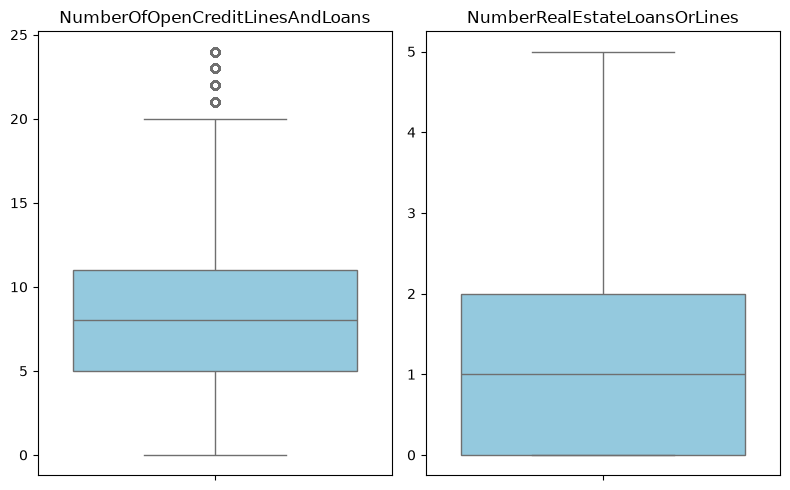

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes = axes.flatten()  

features = ['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']

for i, col in enumerate(features):
    sns.boxplot(data=x_train, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('') 

plt.tight_layout()
plt.show()

as we can see the features were modified

In [23]:
features = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

for df in [x_train, x_cv, x_test]:
    for feature in features:
        df[feature] = np.log1p(df[feature])

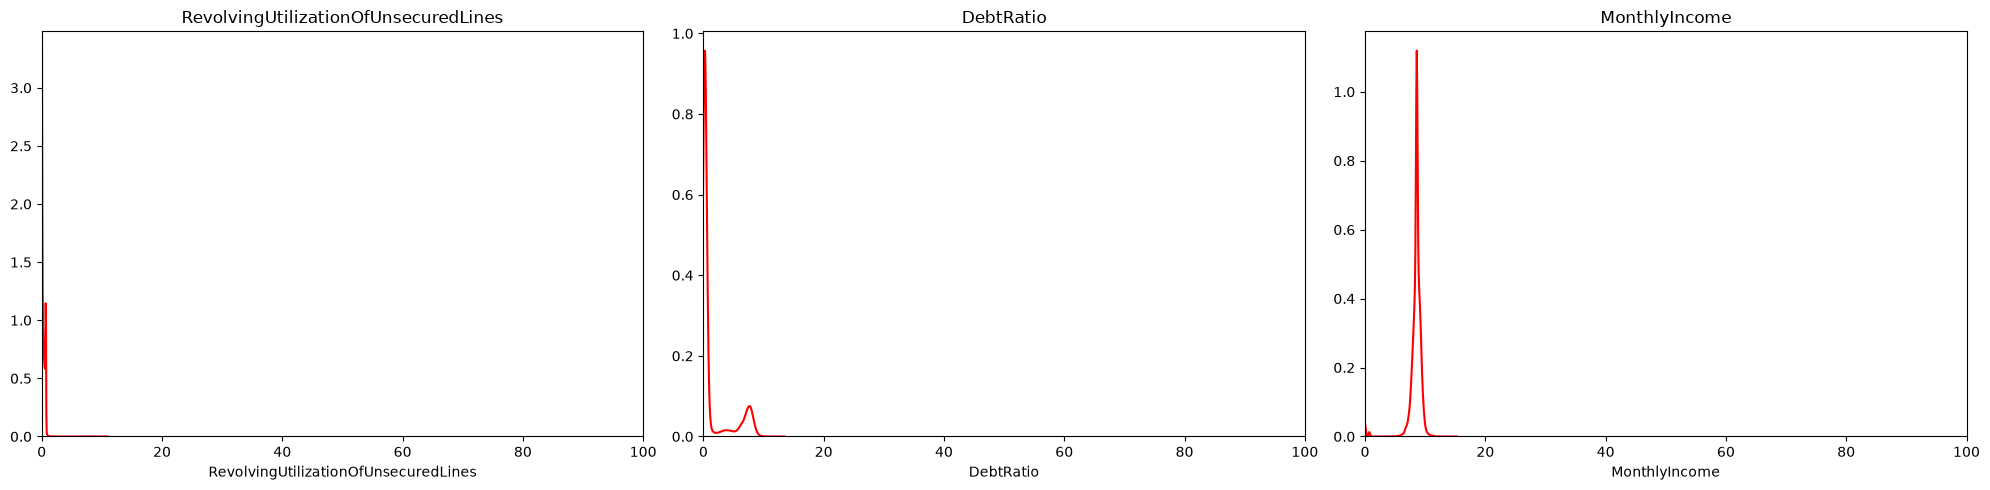

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()  

# continuous features
features = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

for i, col in enumerate(features):
    sns.kdeplot(data=x_train, x=col, ax=axes[i], color='red')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

    if col == 'RevolvingUtilizationOfUnsecuredLines':
        axes[i].set_xlim(0, 100)  
    elif col == 'DebtRatio':
        axes[i].set_xlim(0, 100)  
    elif col == 'MonthlyIncome':
        axes[i].set_xlim(0, 100) 


plt.tight_layout()
plt.show()

the range of the values has changed and density functions also have changed after applying log function